# All Perturbations Preview




In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from torchvision.utils import make_grid


def find_repo_root(start):
    markers = ["main.py", "Datasets", "Models", "Perturbation", "Scripts"]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError("Could not locate repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Resolved REPO_ROOT: {REPO_ROOT}")

from Datasets.unified_dataset_loader import make_default_loader
from Models.dcgan import DCGANGenerator
from Models.pretrained_wrappers import DDIMWrapper, DDPMWrapper, StudioGANWrapper, StyleGAN2Wrapper
from Perturbation.class_assignment_cache import build_label_assignment_context
from Perturbation.class_imbalance import apply_class_imbalance
from Perturbation.class_removal import apply_class_removal
from Perturbation.pipeline_perturbations import (
    _apply_degradation,
    _apply_memoisation,
    _apply_preprocessing_variation,
    _apply_sample_size_variation,
)
from Scripts.evaluation_runtime import load_or_create_real_reference


Resolved REPO_ROOT: c:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics


In [ ]:
DATASET_ROOTS = {
    "mnist": REPO_ROOT / "data" / "MNIST",
    "cifar10": REPO_ROOT / "data" / "CIFAR10",
    "celeba": REPO_ROOT / "data" / "CelebA",
    "chestxray14": REPO_ROOT / "data" / "ChestXray14",
}

DATASET_DEFAULT_IMAGE_SIZES = {
    "mnist": 32,
    "cifar10": 32,
    "celeba": 256,
    "chestxray14": 32,
}

MODEL_PRESETS = {
    ("ddpm", "cifar10"): {
        "label": "DDPM on CIFAR-10",
        "model_type": "ddpm",
        "checkpoint": REPO_ROOT / "checkpoints" / "DDPM" / "CIFAR10",
        "image_size": 32,
        "num_inference_steps": 1000,
    },
    ("ddim", "cifar10"): {
        "label": "DDIM on CIFAR-10",
        "model_type": "ddim",
        "checkpoint": REPO_ROOT / "checkpoints" / "DDPM" / "CIFAR10",
        "image_size": 32,
        "num_inference_steps": 50,
    },
    ("studiogan", "cifar10"): {
        "label": "StudioGAN on CIFAR-10",
        "model_type": "studiogan",
        "checkpoint": REPO_ROOT / "checkpoints" / "StudioGAN" / "CIFAR10" / "studioGAN_generator.pkl",
        "repo_path": REPO_ROOT / "checkpoints" / "StudioGAN" / "CIFAR10" / "studioGAN_src",
        "config_name": "SNGAN.yaml",
        "image_size": 32,
    },
    ("stylegan2", "celeba"): {
        "label": "StyleGAN2 on CelebA",
        "model_type": "stylegan2",
        "checkpoint": REPO_ROOT / "checkpoints" / "StyleGAN" / "CelebA" / "stylegan2_generator.pkl",
        "image_size": 256,
        "truncation_psi": 0.7,
        "noise_mode": "const",
        "class_idx": None,
    },
    ("dcgan", "cifar10"): {
        "label": "DCGAN on CIFAR-10",
        "model_type": "dcgan",
        "checkpoint": REPO_ROOT / "Models" / "saved_weights" / "netG_best.pth",
        "image_size": 32,
        "channels": 3,
        "latent_dim": 100,
        "ngf": 64,
    },
    ("dcgan", "mnist"): {
        "label": "DCGAN on MNIST",
        "model_type": "dcgan",
        "checkpoint": REPO_ROOT / "Models" / "saved_weights" / "netG_epoch_30.pth",
        "image_size": 32,
        "channels": 1,
        "latent_dim": 100,
        "ngf": 64,
    },
}

SUPPORTED_COMBINATIONS = sorted(MODEL_PRESETS.keys())
print("Supported (model, dataset) combinations:")
for model_name, dataset_name in SUPPORTED_COMBINATIONS:
    print(f"- ({model_name!r}, {dataset_name!r})")

# ---- select a model + dataset pair here ----
MODEL_KEY = "stylegan2"
DATASET_KEY = "celeba"

# Optional overrides
DATA_ROOT_OVERRIDE = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 10
DISPLAY_COUNT = 1
POOL_COUNT = None  
DOWNLOAD_IF_MISSING = False


Supported (model, dataset) combinations:
- ('dcgan', 'cifar10')
- ('dcgan', 'mnist')
- ('ddim', 'cifar10')
- ('ddpm', 'cifar10')
- ('studiogan', 'cifar10')
- ('stylegan2', 'celeba')


In [ ]:
def resolve_preset(model_key, dataset_key):
    key = (str(model_key).strip().lower(), str(dataset_key).strip().lower())
    if key not in MODEL_PRESETS:
        raise KeyError(
            f"Unsupported combination {key}. Choose from: {sorted(MODEL_PRESETS.keys())}"
        )
    preset = dict(MODEL_PRESETS[key])
    preset["model_key"] = key[0]
    preset["dataset_key"] = key[1]
    return preset


def resolve_device(device_like):
    device = torch.device(device_like)
    if device.type == "cuda" and not torch.cuda.is_available():
        print("CUDA requested but not available; falling back to CPU.")
        return torch.device("cpu")
    return device


def auto_pool_count(image_size, display_count):
    if int(image_size) >= 256:
        return max(int(display_count), 24)
    if int(image_size) >= 128:
        return max(int(display_count), 48)
    return max(int(display_count), 128)


def choose_domain_shift_dataset(dataset_key):
    mapping = {
        "mnist": "cifar10",
        "cifar10": "mnist",
        "celeba": "cifar10",
        "chestxray14": "cifar10",
    }
    return mapping[str(dataset_key).strip().lower()]


def default_class_target(dataset_key, class_names):
    preferred = {
        "mnist": ["0"],
        "cifar10": ["airplane", "0"],
        "celeba": ["Smiling", "Male", "Young"],
        "chestxray14": ["Atelectasis", "Effusion", "Mass"],
    }
    names = [str(name) for name in list(class_names or [])]
    name_lookup = {name.lower(): name for name in names}
    for candidate in preferred.get(str(dataset_key).strip().lower(), []):
        resolved = name_lookup.get(str(candidate).lower())
        if resolved is not None:
            return resolved
    if names:
        return names[0]
    return "0"


def build_sampler(preset, device):
    model_type = str(preset["model_type"])

    if model_type == "ddpm":
        wrapper = DDPMWrapper(checkpoint_path=str(preset["checkpoint"]))

        def _sample(n: int, seed: int):
            return wrapper.sample(
                int(n),
                device=device,
                seed=int(seed),
                num_inference_steps=int(preset["num_inference_steps"]),
            )

        return _sample

    if model_type == "ddim":
        wrapper = DDIMWrapper(checkpoint_path=str(preset["checkpoint"]))

        def _sample(n: int, seed: int):
            return wrapper.sample(
                int(n),
                device=device,
                seed=int(seed),
                num_inference_steps=int(preset["num_inference_steps"]),
            )

        return _sample

    if model_type == "studiogan":
        wrapper = StudioGANWrapper(
            repo_path=str(preset["repo_path"]),
            ckpt_path=str(preset["checkpoint"]),
            config_name=str(preset["config_name"]),
            device=device,
            logger=None,
        )

        def _sample(n: int, seed: int):
            torch.manual_seed(int(seed))
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(int(seed))
            return wrapper.sample(int(n)).detach().cpu().clamp(-1.0, 1.0)

        return _sample

    if model_type == "stylegan2":
        wrapper = StyleGAN2Wrapper(checkpoint_path=str(preset["checkpoint"]))

        def _sample(n: int, seed: int):
            return wrapper.sample(
                int(n),
                device=device,
                truncation_psi=float(preset["truncation_psi"]),
                noise_mode=str(preset["noise_mode"]),
                class_idx=preset.get("class_idx"),
                seed=int(seed),
            )

        return _sample

    if model_type == "dcgan":
        generator = DCGANGenerator(
            ngpu=0,
            nc=int(preset["channels"]),
            nz=int(preset["latent_dim"]),
            ngf=int(preset["ngf"]),
            image_size=int(preset["image_size"]),
        ).to(device)
        generator.load_state_dict(torch.load(preset["checkpoint"], map_location=device))
        generator.eval()

        def _sample(n: int, seed: int):
            latent_rng = torch.Generator(device=device)
            latent_rng.manual_seed(int(seed))
            noise = torch.randn(
                int(n),
                int(preset["latent_dim"]),
                1,
                1,
                device=device,
                generator=latent_rng,
            )
            with torch.no_grad():
                return generator(noise).detach().cpu().clamp(-1.0, 1.0)

        return _sample

    raise ValueError(f"Unsupported model type: {model_type}")


def _preview_subset(samples, max_images, nrow = None):
    total = int(samples.shape[0])
    if total <= 0:
        return None, 0, 0
    shown = min(int(max_images), total)
    subset = samples[:shown].detach().cpu().float().clamp(-1.0, 1.0)
    subset = ((subset + 1.0) / 2.0).clamp(0.0, 1.0)
    if int(subset.shape[1]) == 1:
        subset = subset.repeat(1, 3, 1, 1)
    nrow = min(int(nrow or 5), shown)
    grid = make_grid(subset, nrow=max(1, nrow), padding=2)
    return grid.permute(1, 2, 0).numpy(), shown, total


def show_side_by_side(
    left_samples: torch.Tensor,
    right_samples: torch.Tensor,
    *,
    title: str,
    left_title: str,
    right_title: str,
    note: str = "",
    max_images: int = 10,
):
    header = f"### {title}"
    if note:
        header += f"\n\n{note}"
    display(Markdown(header))

    left_grid, left_shown, left_total = _preview_subset(left_samples, max_images=max_images)
    right_grid, right_shown, right_total = _preview_subset(right_samples, max_images=max_images)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for axis, grid, shown, total, subtitle in [
        (axes[0], left_grid, left_shown, left_total, left_title),
        (axes[1], right_grid, right_shown, right_total, right_title),
    ]:
        if grid is None:
            axis.text(0.5, 0.5, "No samples", ha="center", va="center", fontsize=12)
        else:
            axis.imshow(grid)
        axis.set_title(f"{subtitle}\n({shown} shown / {total} total)")
        axis.axis("off")
    plt.tight_layout()
    plt.show()


def format_detail_pairs(details, keys) :
    parts = []
    for key in keys:
        if key in details:
            parts.append(f"{key}={details[key]}")
    return "; ".join(parts)


def maybe_raise_missing_path(path_like: Path, label: str):
    path = Path(path_like)
    if not path.exists():
        raise FileNotFoundError(f"{label} not found: {path}")


Preset: StyleGAN2 on CelebA
Device: cpu
Data root: c:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\data\CelebA
Fake pool shape: (24, 3, 256, 256)
Real reference shape: (24, 3, 256, 256)
Suggested class target: Smiling
Class names: 5_o_Clock_Shadow, Arched_Eyebrows, Attractive, Bags_Under_Eyes, Bald, Bangs, Big_Lips, Big_Nose, Black_Hair, Blond_Hair, Blurry, Brown_Hair, Bushy_Eyebrows, Chubby, Double_Chin, Eyeglasses, Goatee, Gray_Hair, Heavy_Makeup, High_Cheekbones ...


### Baseline Preview

Generated pool size=24; display_count=1. If class-based perturbations look unchanged, increase POOL_COUNT and rerun.

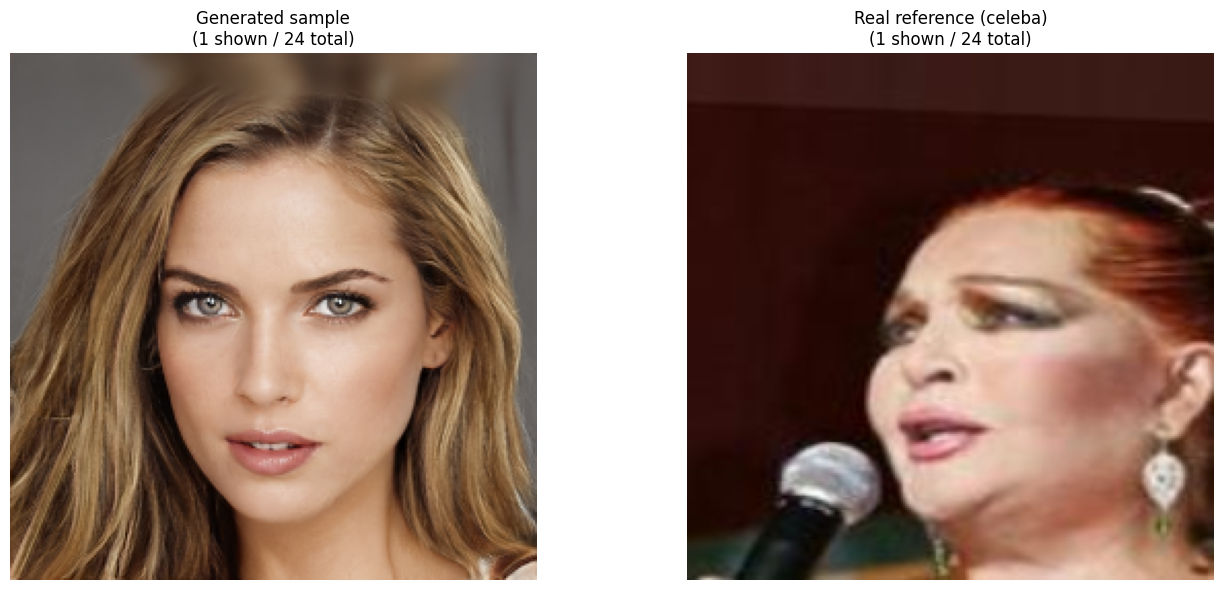

In [6]:
preset = resolve_preset(MODEL_KEY, DATASET_KEY)
device = resolve_device(DEVICE)
data_root = Path(DATA_ROOT_OVERRIDE) if DATA_ROOT_OVERRIDE is not None else DATASET_ROOTS[DATASET_KEY]
pool_count = int(POOL_COUNT) if POOL_COUNT is not None else auto_pool_count(preset["image_size"], DISPLAY_COUNT)

maybe_raise_missing_path(Path(data_root), f"Data root for {DATASET_KEY}")
maybe_raise_missing_path(Path(preset["checkpoint"]), f"Checkpoint for {preset['label']}")
if preset.get("repo_path") is not None:
    maybe_raise_missing_path(Path(preset["repo_path"]), f"Source repo for {preset['label']}")

sampler = build_sampler(preset, device)
fake_pool = sampler(pool_count, SEED)
reference_artifact = load_or_create_real_reference(
    dataset_name=DATASET_KEY,
    data_root=str(data_root),
    image_size=int(preset["image_size"]),
    sample_count=int(pool_count),
    download_if_missing=bool(DOWNLOAD_IF_MISSING),
    seed=int(SEED),
    verbose=False,
)
real_pool = reference_artifact.samples.detach().cpu()
reference_targets = reference_artifact.targets.detach().cpu()
reference_class_names = [str(name) for name in list(reference_artifact.class_names or [])]
resolved_default_target = default_class_target(DATASET_KEY, reference_class_names)

print(f"Preset: {preset['label']}")
print(f"Device: {device}")
print(f"Data root: {data_root}")
print(f"Fake pool shape: {tuple(fake_pool.shape)}")
print(f"Real reference shape: {tuple(real_pool.shape)}")
print(f"Suggested class target: {resolved_default_target}")
if reference_class_names:
    preview_names = reference_class_names[: min(20, len(reference_class_names))]
    suffix = "" if len(reference_class_names) <= 20 else " ..."
    print("Class names:", ", ".join(preview_names) + suffix)

show_side_by_side(
    fake_pool,
    real_pool,
    title="Baseline Preview",
    left_title="Generated sample",
    right_title=f"Real reference ({DATASET_KEY})",
    note=(
        f"Generated pool size={pool_count}; display_count={DISPLAY_COUNT}. "
        "If class-based perturbations look unchanged, increase POOL_COUNT and rerun."
    ),
    max_images=DISPLAY_COUNT,
)


In [21]:
# ---- Perturbation settings ----

# Degradation
DEGRADATION_SEVERITY = 2
DEGRADATION_VARIANTS = [
    ("gaussian_noise", {"gaussian_noise": True, "gaussian_blur": True, "jpeg_compression": True}),
    ("gaussian_blur", {"gaussian_noise": False, "gaussian_blur": True, "jpeg_compression": False}),
    ("jpeg_compression", {"gaussian_noise": False, "gaussian_blur": False, "jpeg_compression": True}),
]

# Memoisation
MEMO_FRACTION = 0.30
MEMO_SEED = SEED

# Class removal / imbalance
CLASS_STRATEGY = "label"   # "label" or "kmeans"
CLASS_TARGETS = None        # None -> uses the suggested target printed above
CLASS_KMEANS_K = 8
CLASS_LABEL_THRESHOLD = 0.0
CLASS_MIN_KEPT = 4
CLASS_REMOVAL_SEED = SEED
CLASS_IMBALANCE_BALANCE = 0.60
CLASS_IMBALANCE_SEED = SEED

# Sample size
SAMPLE_SIZE_N = max(1, DISPLAY_COUNT // 2)
SAMPLE_SIZE_SEED = SEED

# Preprocessing
PREPROCESSING_SCALE = 0.6
PREPROCESSING_VARIANTS = [
    "downsample_nearest",
    "downsample_bilinear",
    "downsample_bicubic",
    "center_crop_pad",
    "grayscale_triplicate",
]

# Domain shift
DOMAIN_SHIFT_DATASET = choose_domain_shift_dataset(DATASET_KEY)
DOMAIN_SHIFT_DATA_ROOT = DATASET_ROOTS[DOMAIN_SHIFT_DATASET]
DOMAIN_SHIFT_IMAGE_SIZE = DATASET_DEFAULT_IMAGE_SIZES[DOMAIN_SHIFT_DATASET]


## Perturbation Outputs

Using class target(s): `Smiling`

### Degradation: gaussian_noise

severity=2

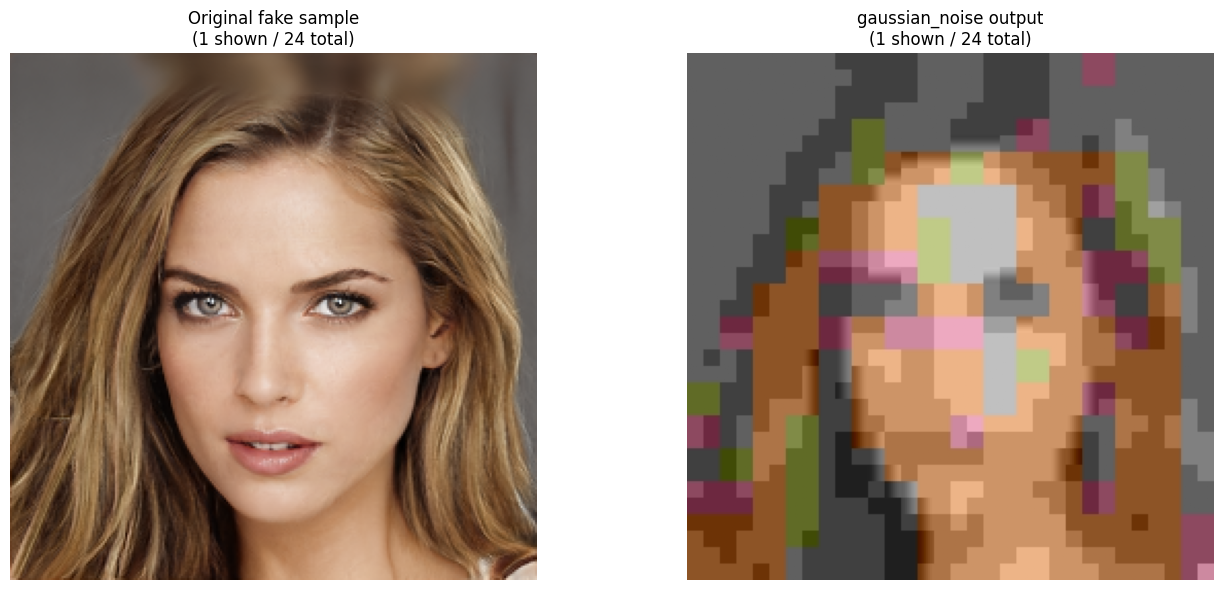

### Degradation: gaussian_blur

severity=2

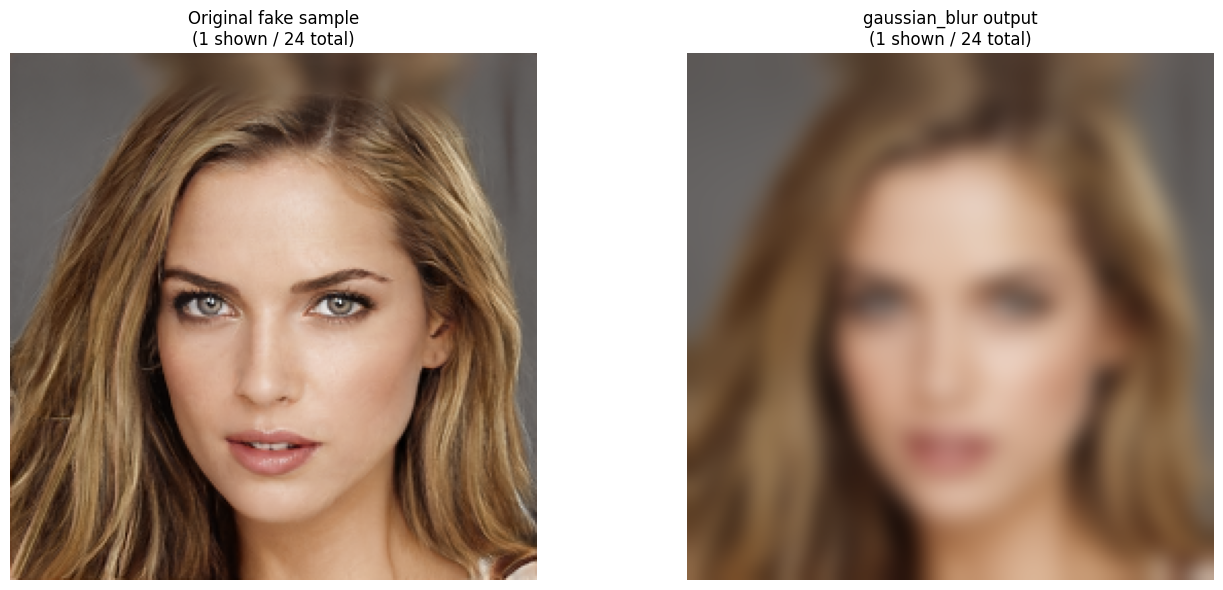

### Degradation: jpeg_compression

severity=2

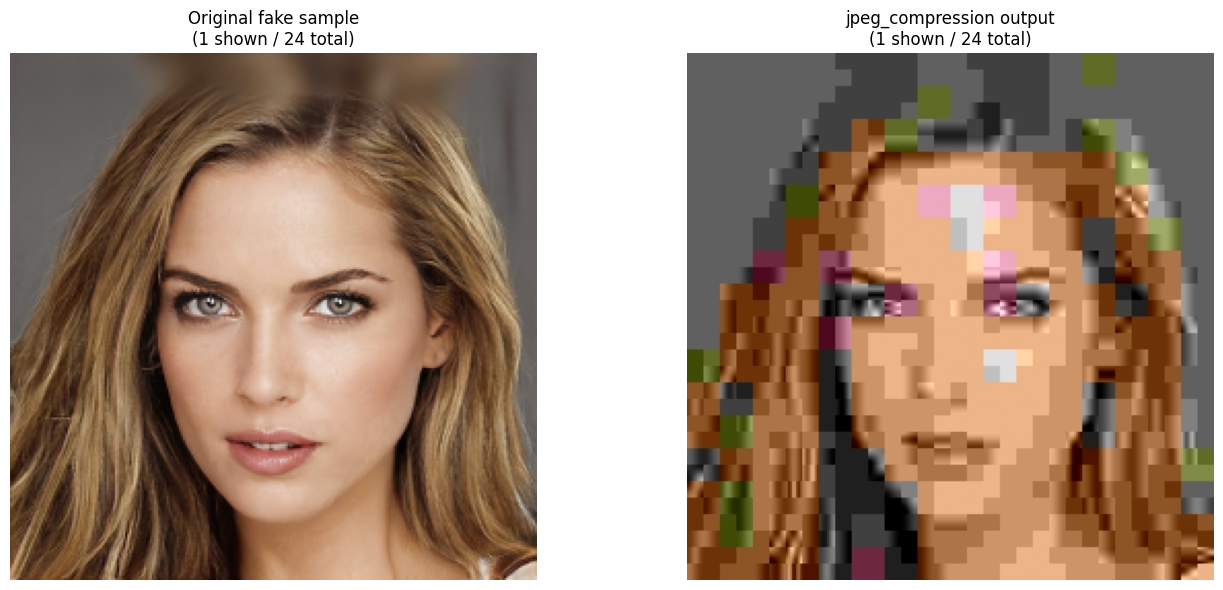

### Memoisation

fraction=0.3; injected_count=7; first_injected_positions=[4, 5, 12, 13, 17, 18, 19]

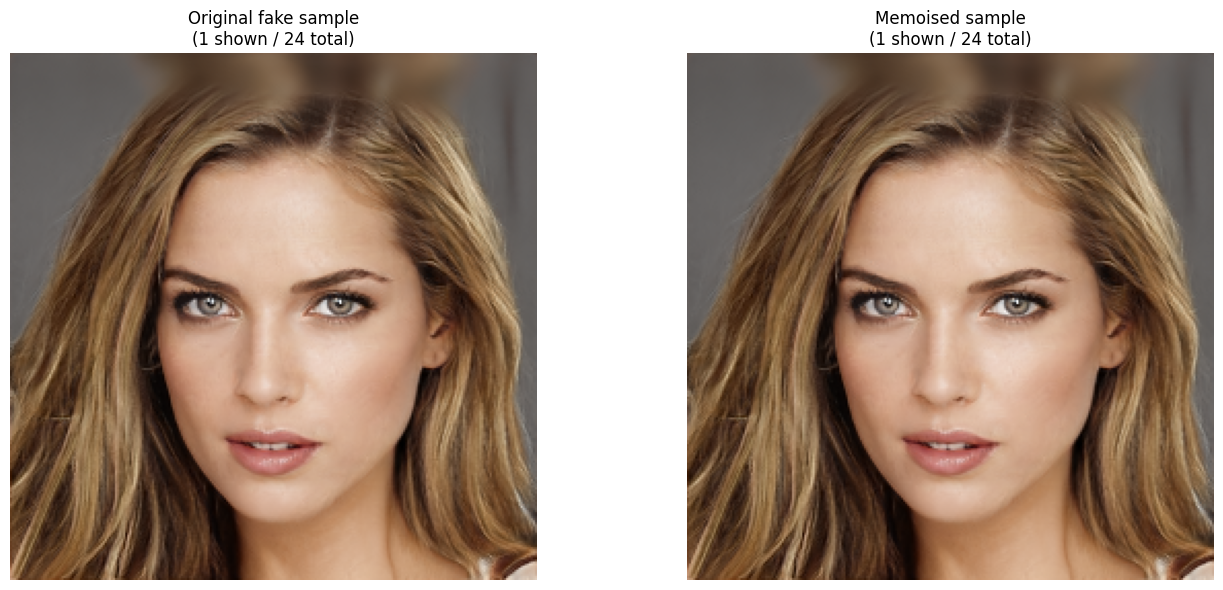

### Class Removal

strategy=label; removed_count=6; kept_count=18

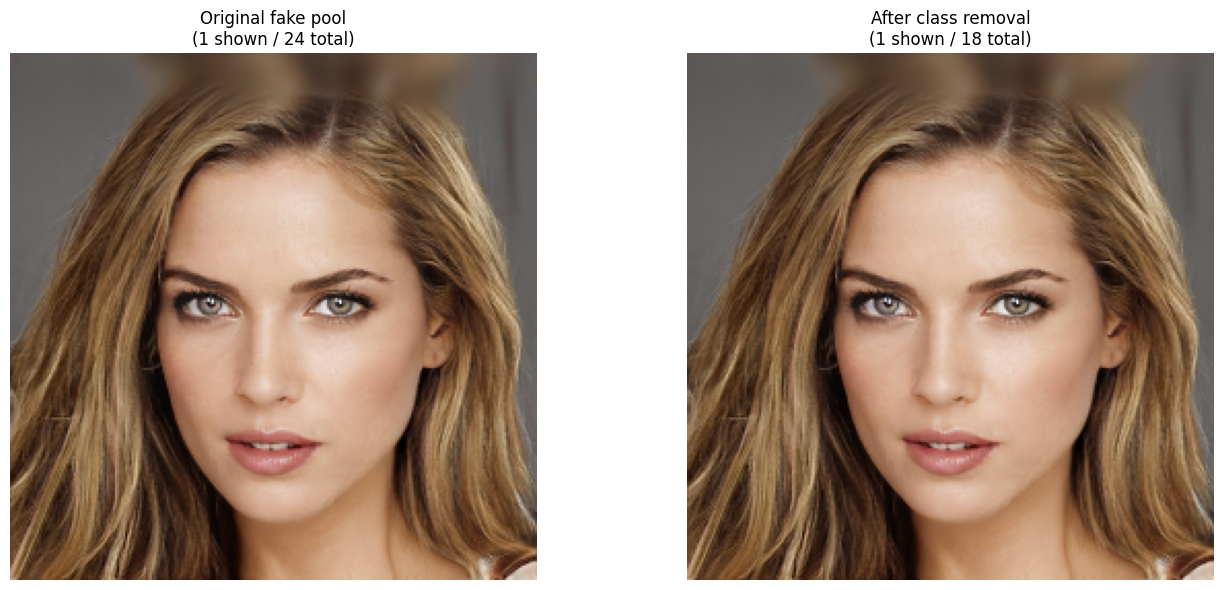

### Class Imbalance

strategy=label; drop_fraction=0.6; removed_count=3; kept_count=21

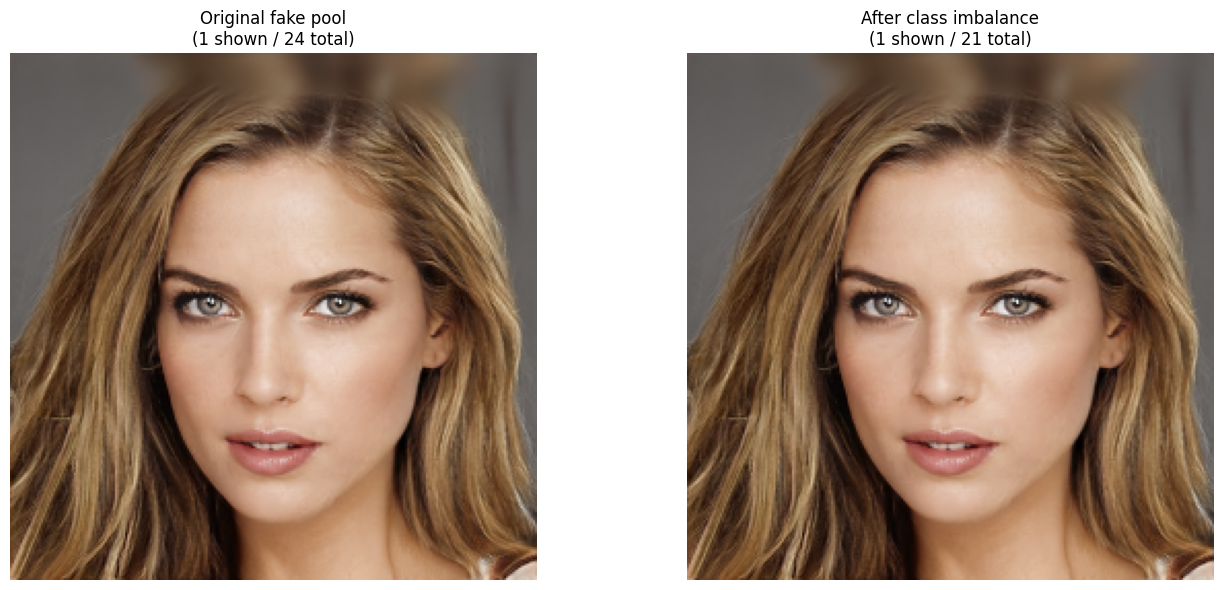

### Sample Size Variation

n=1; selected_indices=[17]

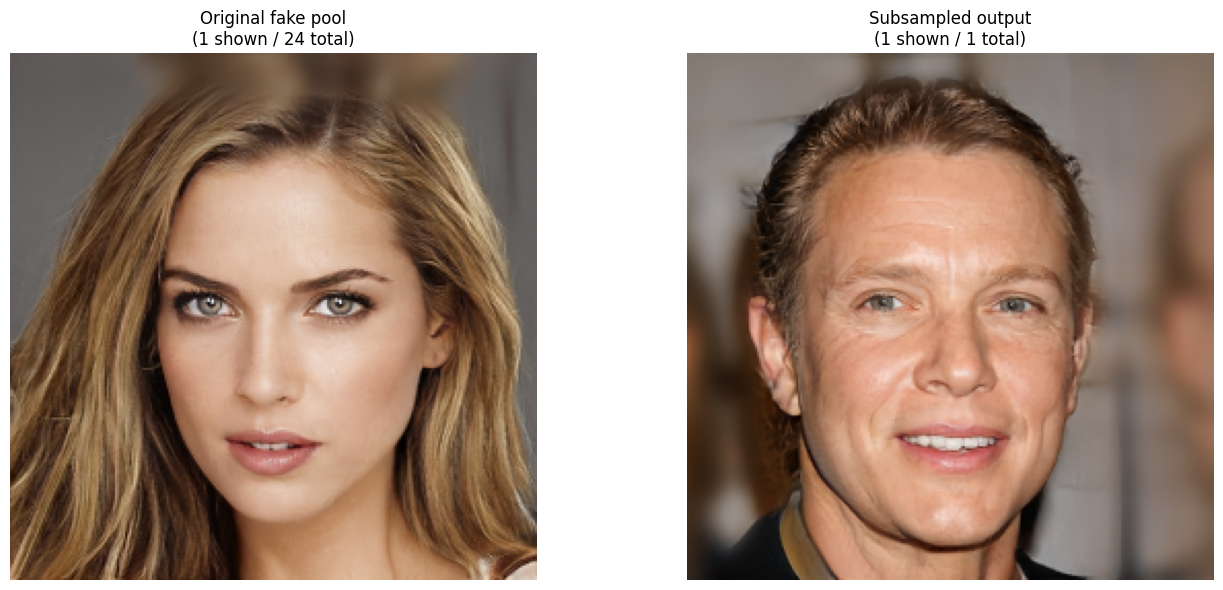

### Preprocessing: downsample_nearest

scale=0.6

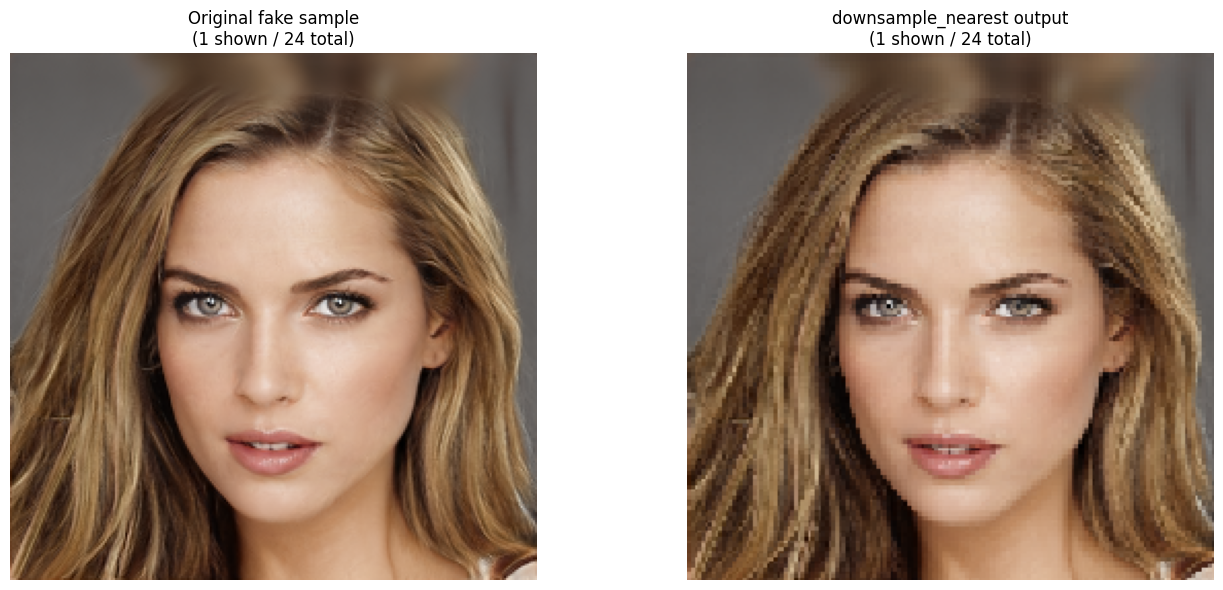

### Preprocessing: downsample_bilinear

scale=0.6

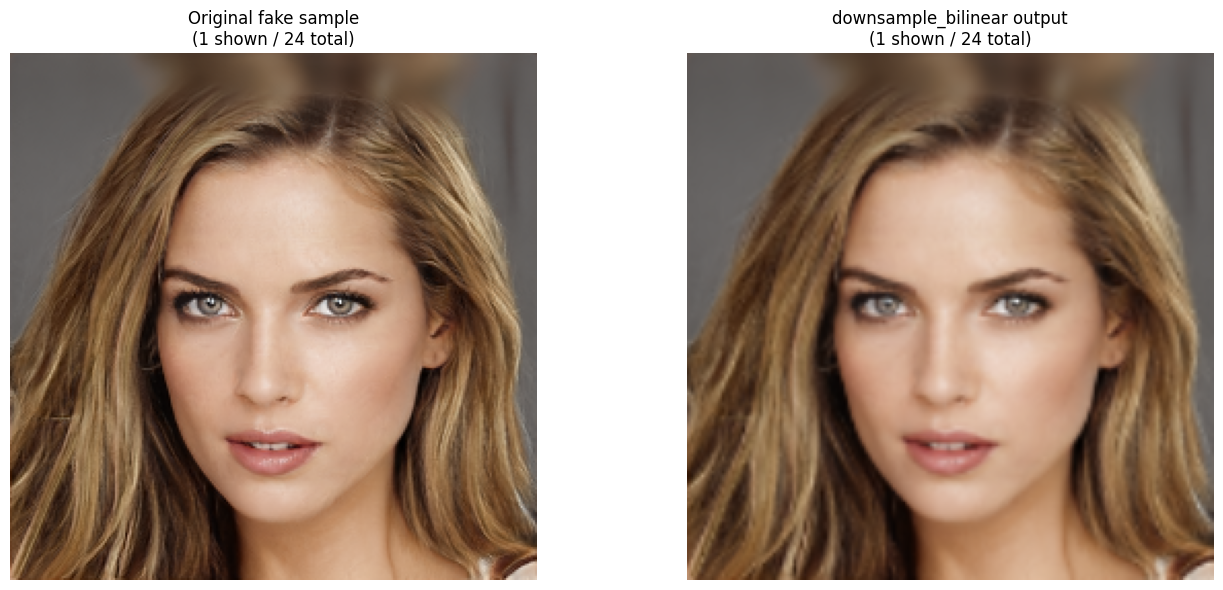

### Preprocessing: downsample_bicubic

scale=0.6

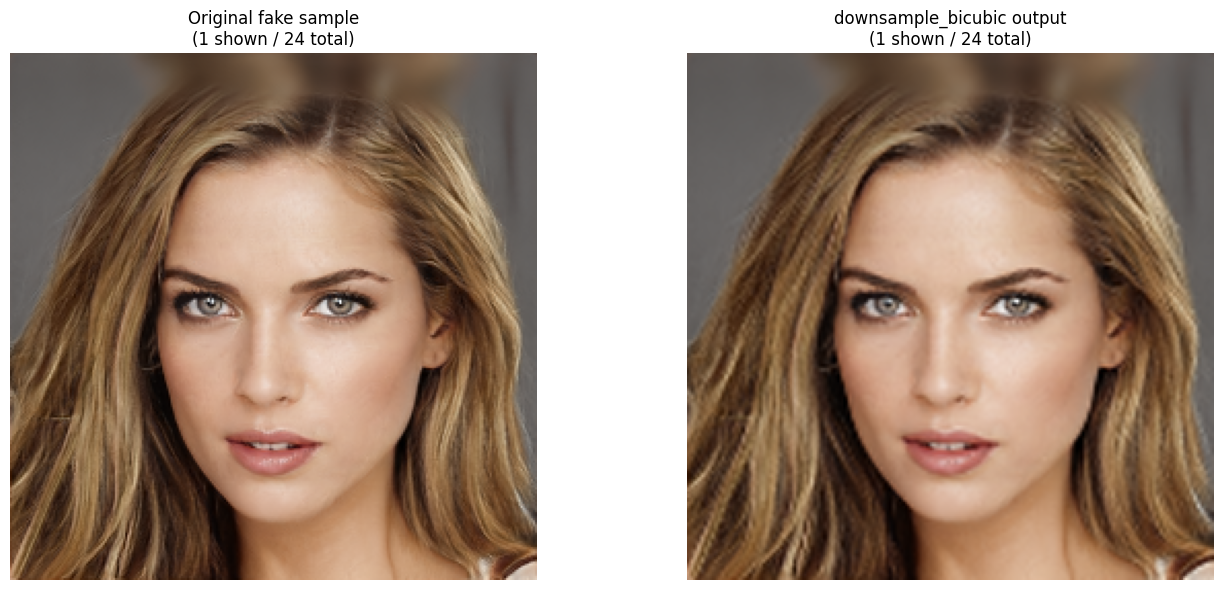

### Preprocessing: center_crop_pad

scale=0.6

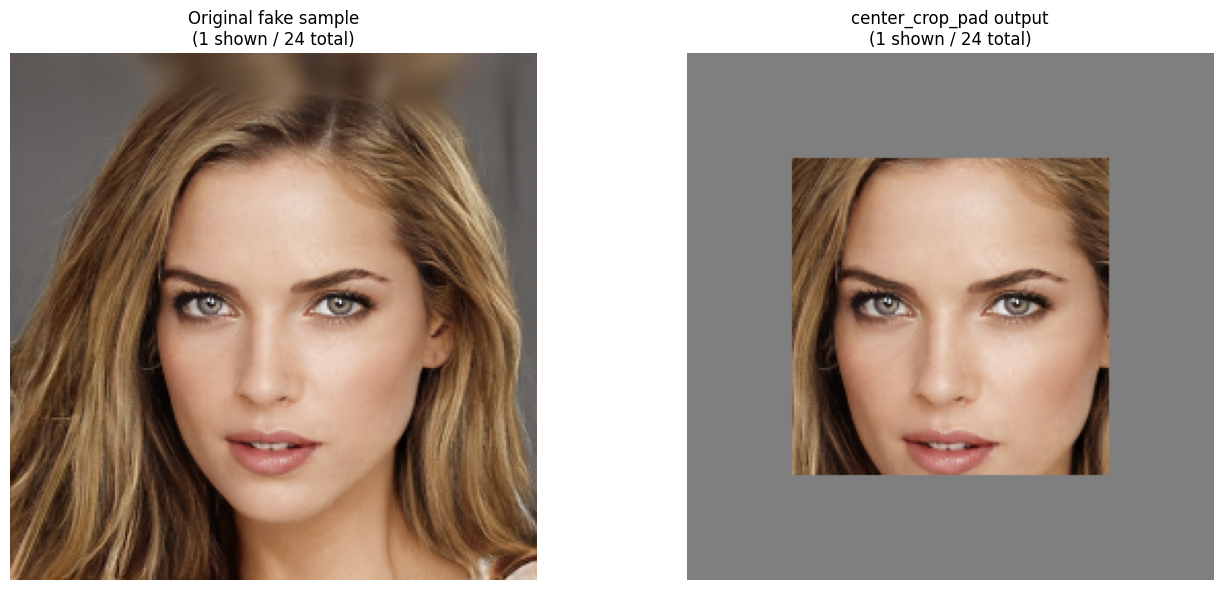

### Preprocessing: grayscale_triplicate

scale=0.6

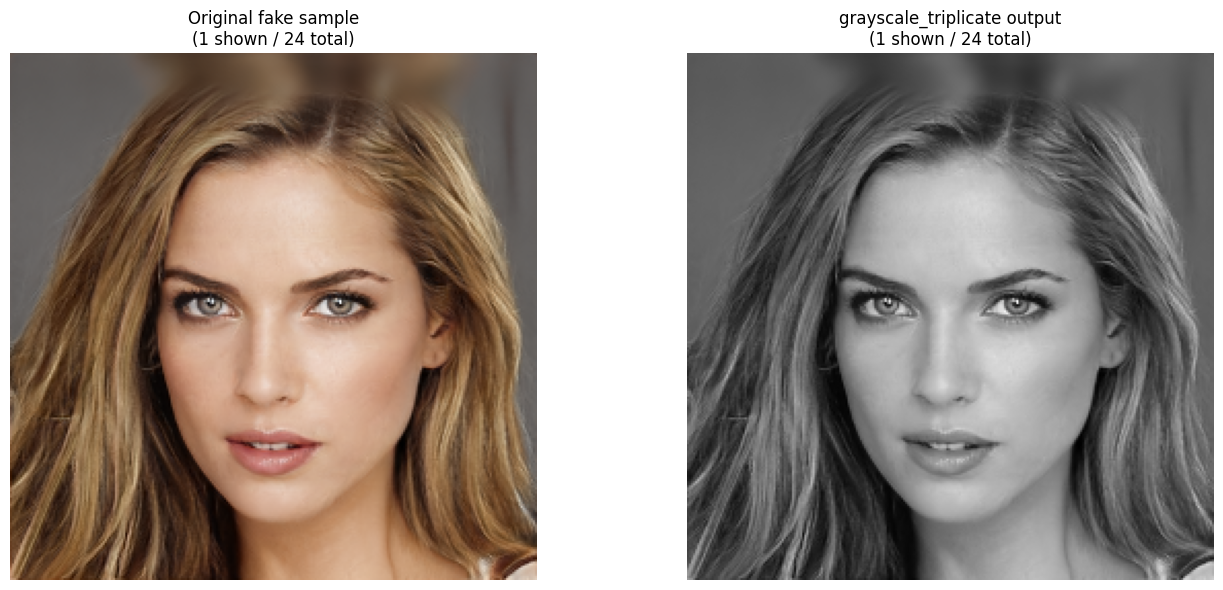

### Domain Shift

Fake samples are unchanged here. Domain shift only swaps the real reference set used for evaluation. image_size=32

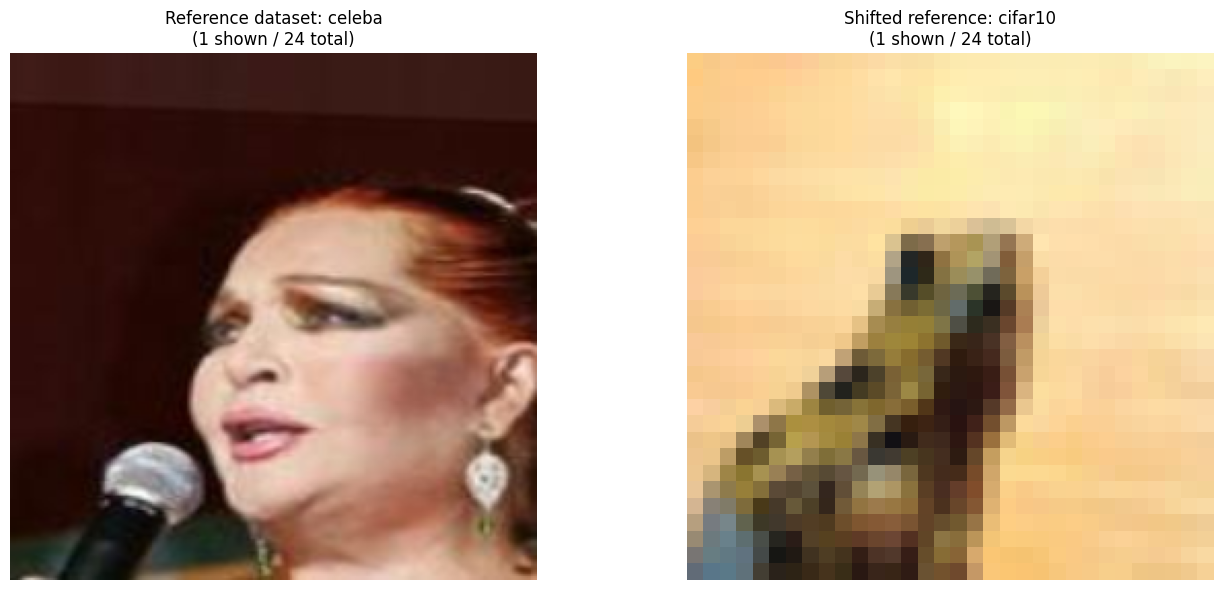

In [22]:
effective_class_targets = (
    str(CLASS_TARGETS).strip() if CLASS_TARGETS not in (None, "") else str(resolved_default_target)
)
display(Markdown(f"## Perturbation Outputs\n\nUsing class target(s): `{effective_class_targets}`"))

for variant_name, variant_flags in DEGRADATION_VARIANTS:
    try:
        degraded = _apply_degradation(
            fake_pool.clone(),
            severity=int(DEGRADATION_SEVERITY),
            gaussian_noise=bool(variant_flags["gaussian_noise"]),
            gaussian_blur=bool(variant_flags["gaussian_blur"]),
            jpeg_compression=bool(variant_flags["jpeg_compression"]),
        )
        show_side_by_side(
            fake_pool,
            degraded,
            title=f"Degradation: {variant_name}",
            left_title="Original fake sample",
            right_title=f"{variant_name} output",
            note=f"severity={DEGRADATION_SEVERITY}",
            max_images=DISPLAY_COUNT,
        )
    except Exception as exc:
        print(f"Degradation preview failed for {variant_name}: {exc}")

try:
    memoised, memo_details = _apply_memoisation(
        fake_samples=fake_pool.clone(),
        real_samples=real_pool.clone(),
        fraction=float(MEMO_FRACTION),
        seed=int(MEMO_SEED),
    )
    show_side_by_side(
        fake_pool,
        memoised,
        title="Memoisation",
        left_title="Original fake sample",
        right_title="Memoised sample",
        note=(
            f"fraction={MEMO_FRACTION}; injected_count={memo_details['injected_count']}; "
            f"first_injected_positions={memo_details['injected_positions'][:10]}"
        ),
        max_images=DISPLAY_COUNT,
    )
except Exception as exc:
    print(f"Memoisation preview failed: {exc}")

try:
    class_runtime_context = {
        "label_assignment_context": build_label_assignment_context(
            fake_samples=fake_pool,
            reference_samples=real_pool,
            reference_targets=reference_targets,
            class_names=reference_class_names,
        ),
        "class_fixed_eval_enabled": False,
        "class_evaluation_count": 0,
    }

    class_removal_config = {
        "strategy": str(CLASS_STRATEGY),
        "targets_raw": str(effective_class_targets),
        "kmeans_k": int(CLASS_KMEANS_K),
        "kmeans_cache_path": "",
        "kmeans_recreate": False,
        "seed": int(CLASS_REMOVAL_SEED),
        "label_threshold": float(CLASS_LABEL_THRESHOLD),
        "min_kept": int(CLASS_MIN_KEPT),
        "out_dir": "",
    }
    removed, removal_details = apply_class_removal(
        fake_samples=fake_pool.clone(),
        config=class_removal_config,
        real_samples=real_pool.clone(),
        reference_targets=reference_targets,
        reference_class_names=reference_class_names,
        dataset_name=DATASET_KEY,
        runtime_context=class_runtime_context,
    )
    removal_note = (
        f"strategy={removal_details.get('strategy', CLASS_STRATEGY)}; "
        f"removed_count={removal_details.get('removed_count')}; kept_count={removal_details.get('kept_count')}"
    )
    if int(removal_details.get("removed_count", 0)) == 0:
        removal_note += "; no samples matched the target in this pool, so try another target or larger POOL_COUNT"
    show_side_by_side(
        fake_pool,
        removed,
        title="Class Removal",
        left_title="Original fake pool",
        right_title="After class removal",
        note=removal_note,
        max_images=DISPLAY_COUNT,
    )
except Exception as exc:
    print(f"Class removal preview failed: {exc}")

try:
    class_imbalance_config = {
        "strategy": str(CLASS_STRATEGY),
        "targets_raw": str(effective_class_targets),
        "balance": float(CLASS_IMBALANCE_BALANCE),
        "kmeans_k": int(CLASS_KMEANS_K),
        "kmeans_cache_path": "",
        "kmeans_recreate": False,
        "seed": int(CLASS_IMBALANCE_SEED),
        "label_threshold": float(CLASS_LABEL_THRESHOLD),
        "min_kept": int(CLASS_MIN_KEPT),
        "out_dir": "",
    }
    imbalanced, imbalance_details = apply_class_imbalance(
        fake_samples=fake_pool.clone(),
        config=class_imbalance_config,
        real_samples=real_pool.clone(),
        reference_targets=reference_targets,
        reference_class_names=reference_class_names,
        dataset_name=DATASET_KEY,
        runtime_context=class_runtime_context,
    )
    imbalance_note = (
        f"strategy={imbalance_details.get('strategy', CLASS_STRATEGY)}; "
        f"drop_fraction={CLASS_IMBALANCE_BALANCE}; removed_count={imbalance_details.get('removed_count')}; "
        f"kept_count={imbalance_details.get('kept_count')}"
    )
    if int(imbalance_details.get("removed_count", 0)) == 0:
        imbalance_note += "; no samples were thinned in this pool, so try another target or larger POOL_COUNT"
    show_side_by_side(
        fake_pool,
        imbalanced,
        title="Class Imbalance",
        left_title="Original fake pool",
        right_title="After class imbalance",
        note=imbalance_note,
        max_images=DISPLAY_COUNT,
    )
except Exception as exc:
    print(f"Class imbalance preview failed: {exc}")

try:
    sampled, selected_indices = _apply_sample_size_variation(
        fake_pool.clone(),
        n=int(SAMPLE_SIZE_N),
        seed=int(SAMPLE_SIZE_SEED),
    )
    show_side_by_side(
        fake_pool,
        sampled,
        title="Sample Size Variation",
        left_title="Original fake pool",
        right_title="Subsampled output",
        note=f"n={SAMPLE_SIZE_N}; selected_indices={selected_indices[:15]}",
        max_images=DISPLAY_COUNT,
    )
except Exception as exc:
    print(f"Sample-size preview failed: {exc}")

for variant_name in PREPROCESSING_VARIANTS:
    try:
        preprocessed = _apply_preprocessing_variation(
            fake_pool.clone(),
            variant=str(variant_name),
            scale=float(PREPROCESSING_SCALE),
        )
        show_side_by_side(
            fake_pool,
            preprocessed,
            title=f"Preprocessing: {variant_name}",
            left_title="Original fake sample",
            right_title=f"{variant_name} output",
            note=f"scale={PREPROCESSING_SCALE}",
            max_images=DISPLAY_COUNT,
        )
    except Exception as exc:
        print(f"Preprocessing preview failed for {variant_name}: {exc}")

try:
    maybe_raise_missing_path(Path(DOMAIN_SHIFT_DATA_ROOT), f"Domain-shift root for {DOMAIN_SHIFT_DATASET}")
    shifted_reference = load_or_create_real_reference(
        dataset_name=str(DOMAIN_SHIFT_DATASET),
        data_root=str(DOMAIN_SHIFT_DATA_ROOT),
        image_size=int(DOMAIN_SHIFT_IMAGE_SIZE),
        sample_count=int(pool_count),
        download_if_missing=bool(DOWNLOAD_IF_MISSING),
        seed=int(SEED),
        verbose=False,
    )
    show_side_by_side(
        real_pool,
        shifted_reference.samples.detach().cpu(),
        title="Domain Shift",
        left_title=f"Reference dataset: {DATASET_KEY}",
        right_title=f"Shifted reference: {DOMAIN_SHIFT_DATASET}",
        note=(
            "Fake samples are unchanged here. Domain shift only swaps the real reference set used for evaluation. "
            f"image_size={DOMAIN_SHIFT_IMAGE_SIZE}"
        ),
        max_images=DISPLAY_COUNT,
    )
except Exception as exc:
    print(f"Domain-shift preview failed: {exc}")
